# Analyse Exploratoire

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Import des modules

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Analyse Exploratoire

In [ ]:
building_consumption = pd.read_csv("/content/drive/MyDrive/2016_Building_Energy_Benchmarking.csv")

In [ ]:
# On regarde comment un batiment est défini dans ce jeu de données
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [ ]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type
building_consumption.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

#### TERMINER L'ANALYSE EXPLORATOIRE

A réaliser :
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse :

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet.

3376 bâtiments

46 colonnes

Mélange de :
données d'identification (adresse, ville, latitude, longitude…)

caractéristiques du bâtiment (Surface GFA, étages, année de construction…)

consommations énergétiques (Electricity, Gas, Steam…)

performance (ENERGYSTARScore, GHG emissions…)

Dataset riche mais hétérogène, avec beaucoup de colonnes qui n’ont pas d'utilité énergétique directe.

In [ ]:
missing = building_consumption.isna().mean().sort_values(ascending=False)
missing


,0
Comments,1.000000
Outlier,0.990521
YearsENERGYSTARCertified,0.964751
ThirdLargestPropertyUseType,0.823460
ThirdLargestPropertyUseTypeGFA,0.823460
SecondLargestPropertyUseType,0.502666
SecondLargestPropertyUseTypeGFA,0.502666
ENERGYSTARScore,0.249704
LargestPropertyUseTypeGFA,0.005924
LargestPropertyUseType,0.005924


In [ ]:
# Comments → 100% manquant, à supprimer.

# ThirdLargestPropertyUseType* → plus de 80% manquants

# YearsENERGYSTARCertified → ~96% manquants

# Certaines colonnes SecondLargestPropertyUseType → 50% vides, à discuter selon besoin

# ➡️ Argument : un modèle ou une analyse ne pourra rien tirer de colonnes vides → on les supprime.

cols_to_drop_missing = missing[missing > 0.6].index
building_clean = building_consumption.drop(columns=cols_to_drop_missing)

In [ ]:
#on enleve tout ce qui ets textuel car aucune valeur ajoutee
cols_text = [
    'PropertyName', 'Address', 'TaxParcelIdentificationNumber',
    'ListOfAllPropertyUseTypes'
]
building_clean = building_clean.drop(columns=cols_text, errors='ignore')


In [ ]:
const_cols = [
    col for col in building_consumption.columns
    if building_consumption[col].nunique(dropna=False) <= 1
]

const_cols


['DataYear', 'City', 'State', 'Comments']

In [ ]:

#le dataset recupere la meme annee , meme ville et etat et pas de comment aucune valeur ajoutee on drop
building_clean = building_consumption.drop(columns=['DataYear', 'City', 'State', 'Comments'])



In [ ]:
#Analyse descriptive
building_clean.describe(include='all').T



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
OSEBuildingID,3376.0,NaN,NaN,NaN,21208.991114,12223.757015,1.0,19990.75,23112.0,25994.25,50226.0
BuildingType,3376,8,NonResidential,1460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PrimaryPropertyType,3376,24,Low-Rise Multifamily,987,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PropertyName,3376,3362,Northgate Plaza,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Address,3376,3354,309 South Cloverdale Street,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZipCode,3360.0,NaN,NaN,NaN,98116.949107,18.615205,98006.0,98105.0,98115.0,98122.0,98272.0
TaxParcelIdentificationNumber,3376,3268,1625049001,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CouncilDistrictCode,3376.0,NaN,NaN,NaN,4.439277,2.120625,1.0,3.0,4.0,7.0,7.0
Neighborhood,3376,19,DOWNTOWN,573,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,3376.0,NaN,NaN,NaN,47.624033,0.047758,47.49917,47.59986,47.618675,47.657115,47.73387


 1. Colonnes d’identification
OSEBuildingID

count = 3376: pas de valeurs manquantes.

Distribution très large (min=1, max=50226) → identifiants uniques.

Aucune valeur répétée → colonne purement technique, à exclure de toute modélisation.

 2. Colonnes catégorielles descriptives
BuildingType

8 catégories différentes.

Majorité : “NonResidential” (1460 occurrences).

Donnée propre, bien répartie, utile pour segmentation.

PrimaryPropertyType

24 types, le plus fréquent : “Low-Rise Multifamily” (987).

Très hétérogène → important : ce type influence fortement les usages énergétiques.

PropertyName / Address

3362–3354 valeurs uniques → quasi uniques.

Faible intérêt analytique → à supprimer.

Neighborhood

19 quartiers, DOWNTOWN dominant (573).

Très utile pour analyses géographiques.

3. Colonnes géographiques (Latitude / Longitude)
Latitude / Longitude

Pas de valeurs manquantes.


4. Informations structurelles du bâtiment
YearBuilt

Moyenne : 1968

Min : 1900 ; Max : 2015

Distribuée sur >100 ans → peut expliquer des différences énergétiques.

NumberofBuildings

Moyenne ≈ 1 (souvent un seul bâtiment).

 extrême : 111 bâtiments

NumberofFloors

Médiane : 4 étages.
extreme 99 étages → probablement une tour (ou une erreur).

PropertyGFA (surfaces)

Toutes les colonnes GFA ont des valeurs extrêmes énormes (max = 9 320 156 ft²).
→ Possibles erreurs de saisie ou très gros complexes industriels/commerciaux.

🔹 5. Colonnes d’usage du bâtiment
Largest / Second / Third Property Use Type**

Beaucoup de valeurs manquantes pour 2ᵉ et 3ᵉ type → utiles pour détecter mono-usage vs multi-usage.

Les colonnes ThirdLargest* ont très peu de données → à supprimer.

 6. Certification ENERGY STAR
YearsENERGYSTARCertified

Très peu remplie (119 lignes).

Valeurs peu informatives sans traitement lourd →
ENERGYSTARScore

2533 valeurs sur 3376.

Moyenne : 68

🔹 7. Indicateurs d’intensité énergétique (EUI)
SiteEUI, SourceEUI

Moyennes autour de 55–135 kBtu/sf.

Max extrêmement élevé (834 kBtu/sf pour SiteEUI ou 2620 kBtu/sf pour SourceEUI)

🔹 8. Consommations totales (kBtu, kWh, therms)

Toutes ces colonnes montrent :

Distribution extrême

Valeurs négatives
Fortes disparités : certains bâtiments sont immenses (centres commerciaux, hôpitaux).
 9. Gaz à effet de serre (GHG)
TotalGHGEmissions

Moyenne : 120

Max : 16 870 → énormes variations

Min négatif : –0.8 → impossible → erreur de donnée.

GHGEmissionsIntensity

Moyenne : 1.17

Max : 34

Min : –0.02 → encore incohérent.

10. Colonnes qualitatives diverses
DefaultData

2 valeurs : True/False

Dominante : False (3263)
→ Peut servir à détecter les données complétées automatiquement.

ComplianceStatus

 catégories, “Compliant” = 3211
→ Dataset largement conforme → pas très discriminant.

Outlier

Seulement 32 lignes marquées comme outliers.
→ Trop peu représentatif, mais utile pour validation d’anomalies.

# Modélisation

In [ ]:
cols_to_drop = [
    'DataYear',
    'City',
    'State',
    'Comments',
    'PropertyName',
    'Address',
    'TaxParcelIdentificationNumber',
    'ThirdLargestPropertyUseType',
    'ThirdLargestPropertyUseTypeGFA',
    'YearsENERGYSTARCertified',
    'Outlier',
    'DefaultData'
]
building_clean = building_consumption.drop(columns=cols_to_drop, errors='ignore')


In [ ]:
# Détecter mono-usage vs multi-usage
building_clean["is_multi_use"] = (
    building_clean["SecondLargestPropertyUseType"].notna() |
    building_clean["LargestPropertyUseType"].notna()
)

HISTOGRAMME DES VARIABLES ENREGISTREES

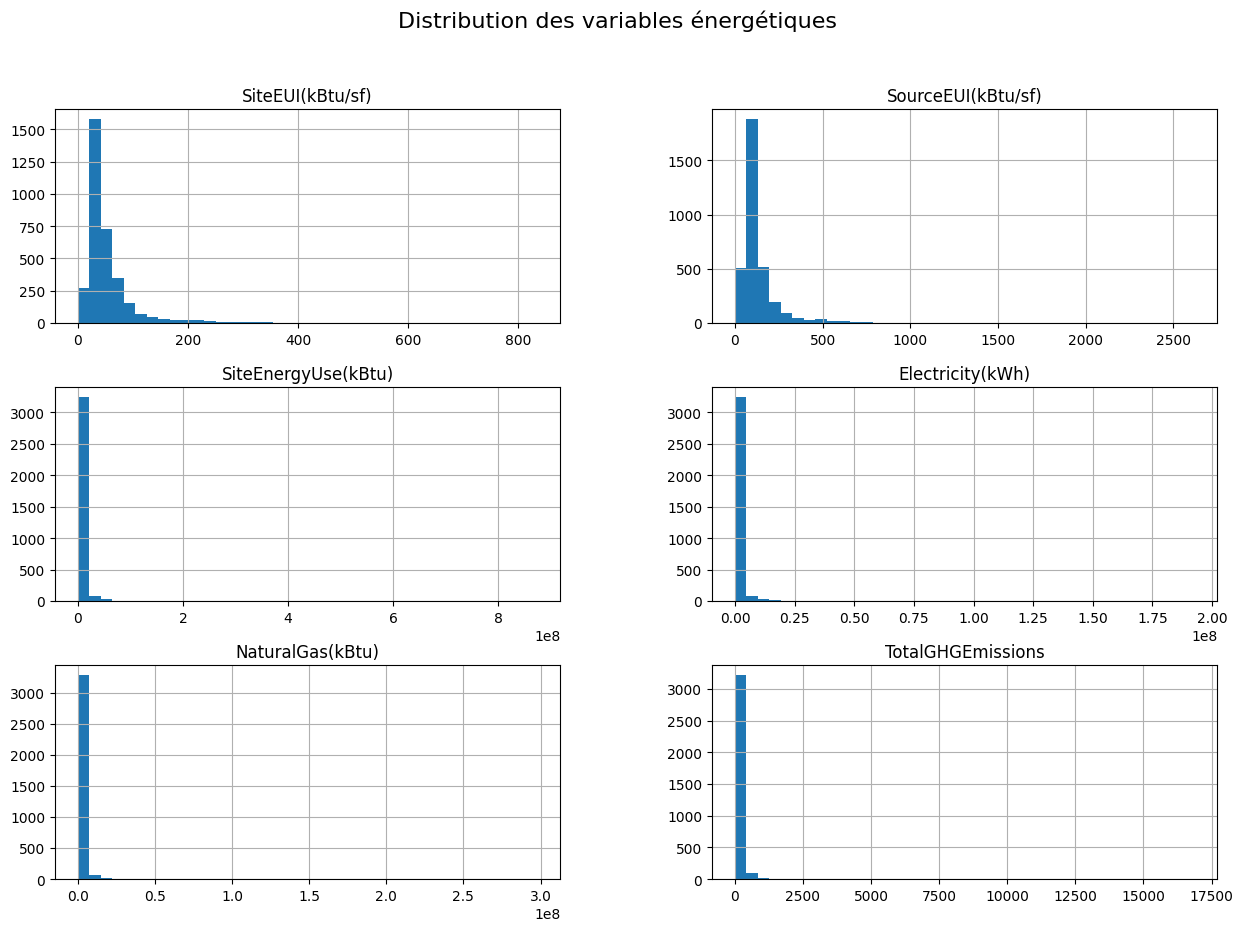

In [ ]:
energy_cols = [
    "SiteEUI(kBtu/sf)", "SourceEUI(kBtu/sf)", "SiteEnergyUse(kBtu)",
    "Electricity(kWh)", "NaturalGas(kBtu)", "TotalGHGEmissions"
]

building_clean[energy_cols].hist(figsize=(15, 10), bins=40)
plt.suptitle("Distribution des variables énergétiques", fontsize=16)
plt.show()


Les histogrammes des variables énergétiques révèlent une forte asymétrie positive (“right-skewed distribution”). La majorité des bâtiments présentent des consommations faibles ou modérées, tandis qu’une minorité montre des consommations extrêmement élevées. Cette structure est typique des données énergétiques réelles et indique :

• une grande hétérogénéité des bâtiments,
• la présence de très grands consommateurs (bureaux, hôpitaux, data centers),
• et des valeurs aberrantes qui devront être traitées avant la modélisation.

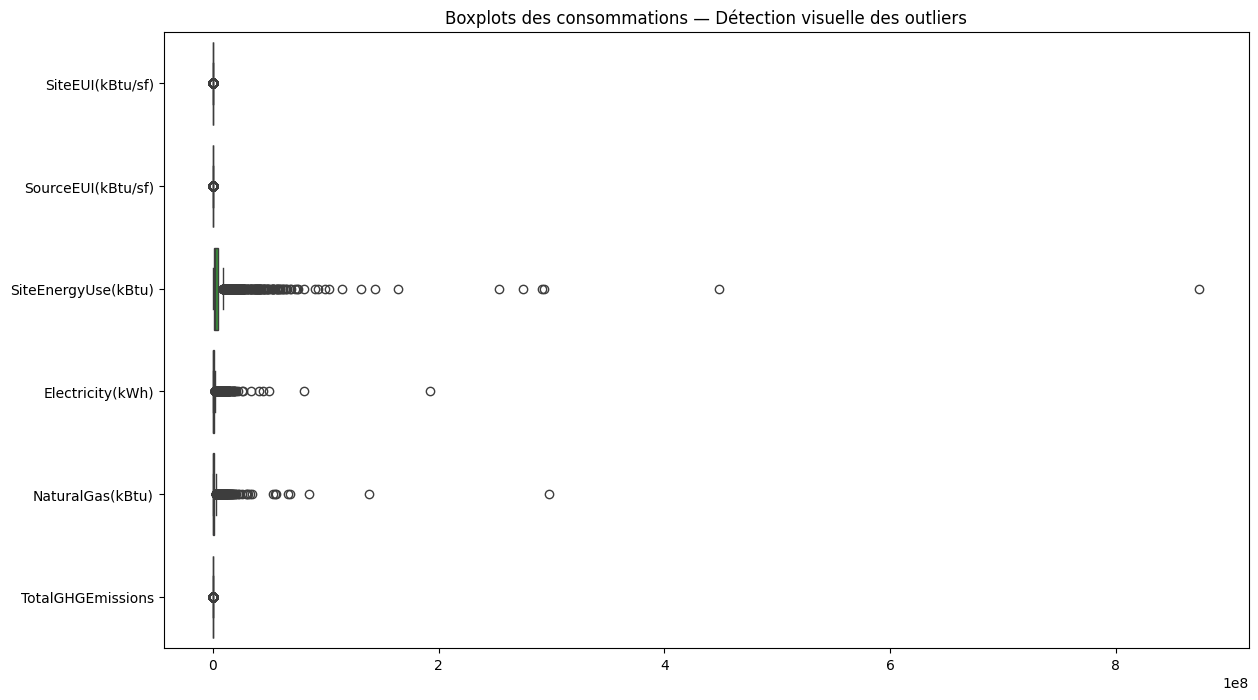

In [ ]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=building_clean[energy_cols], orient='h')
plt.title("Boxplots des consommations — Détection visuelle des outliers")
plt.show()


Sur les boxplots, les outliers apparaissent sous forme de points situés à droite des moustaches. Ils correspondent aux bâtiments ayant des consommations particulièrement élevées (ou des valeurs incohérentes). Dans notre dataset énergétique, la majorité des outliers se trouvent à droite car les variables énergétiques présentent une forte asymétrie positive (quelques bâtiments très énergivores tirent la distribution vers le haut).

DISTRIBUTION GEOGRAPHIQUE(LATTITUDE/LONGITUDE)

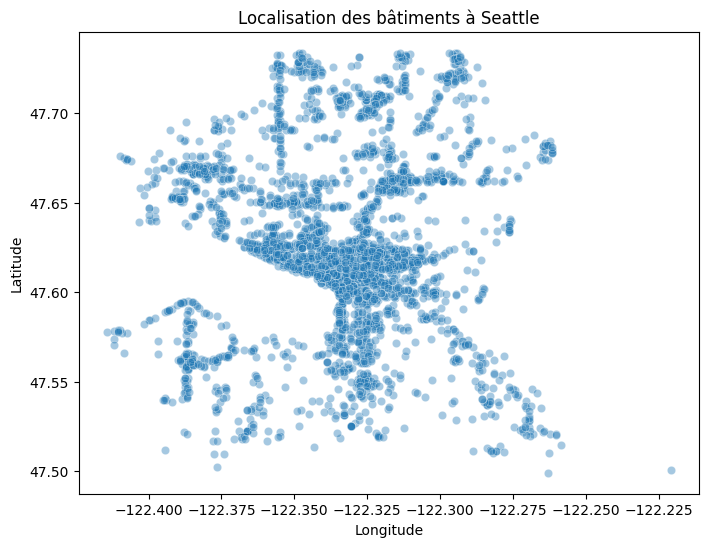

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=building_clean, x="Longitude", y="Latitude", alpha=0.4)
plt.title("Localisation des bâtiments à Seattle")
plt.show()


cohérent pas de valeur extreme on couvre bien Seattle

Repartition mono usage vs multi usageRe

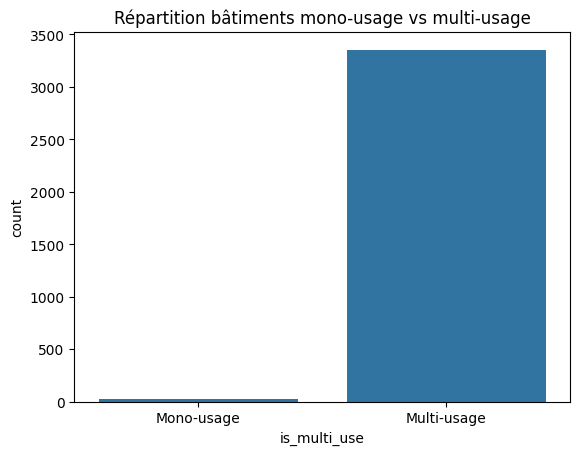

In [ ]:
sns.countplot(data=building_clean, x="is_multi_use")
plt.title("Répartition bâtiments mono-usage vs multi-usage")
plt.xticks([0,1], ["Mono-usage","Multi-usage"])
plt.show()


Consommation mono vs multi usage

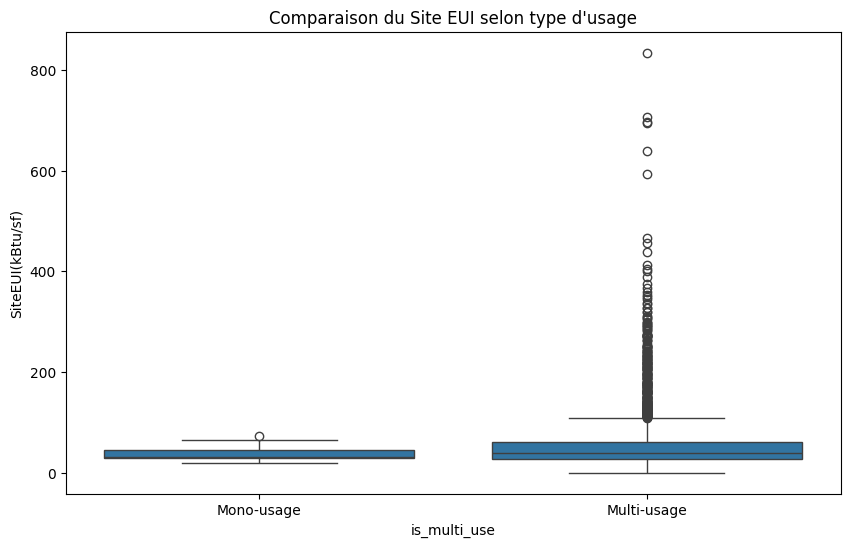

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=building_clean, x="is_multi_use", y="SiteEUI(kBtu/sf)")
plt.xticks([0,1], ["Mono-usage","Multi-usage"])
plt.title("Comparaison du Site EUI selon type d'usage")
plt.show()


Mono usage +homogene alors que quelques outlierss pr le multi car distribution plus large et donc consommation variable

Correlation visuelle

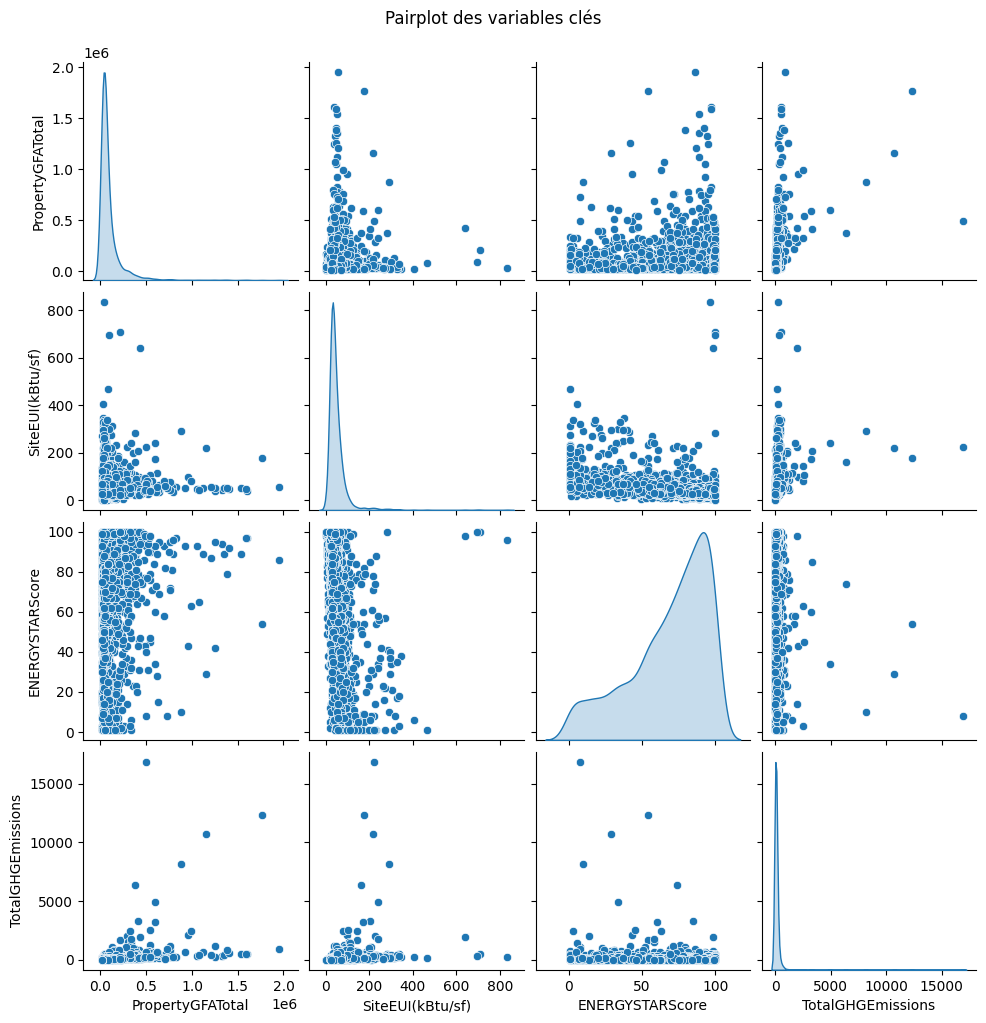

In [ ]:
sns.pairplot(
    building_clean[[
        "PropertyGFATotal",
        "SiteEUI(kBtu/sf)",
        "ENERGYSTARScore",
        "TotalGHGEmissions"
    ]].dropna(),
    diag_kind="kde"
)
plt.suptitle("Pairplot des variables clés", y=1.02)
plt.show()


e pairplot permet de visualiser simultanément la distribution de chaque variable ainsi que leurs relations deux à deux. Les diagonales montrent les distributions individuelles tandis que les cellules hors diagonale affichent des nuages de points révélant les corrélations. Dans ce dataset, on observe une relation positive entre la taille d’un bâtiment (GFA) et ses émissions GES, une relation négative entre l’EUI et le score ENERGY STAR, et une forte asymétrie dans les distributions énergétiques. Les scatterplots montrent également de nombreux outliers pour les grandes consommations.

In [ ]:
HEATMAP ➡️ Elle montre le degré de corrélation entre chaque paire de variables numériques.
➡️ C’est une grille où chaque case représente la corrélation entre deux variables.


🔵 corrélation négative → quand une variable augmente, l’autre diminue

🔴 corrélation positive → les deux augmentent ensemble

⚪ corrélation proche de 0 → pas de relation

Les intensités :

couleur foncée = corrélation forte

couleur claire = corrélation faible

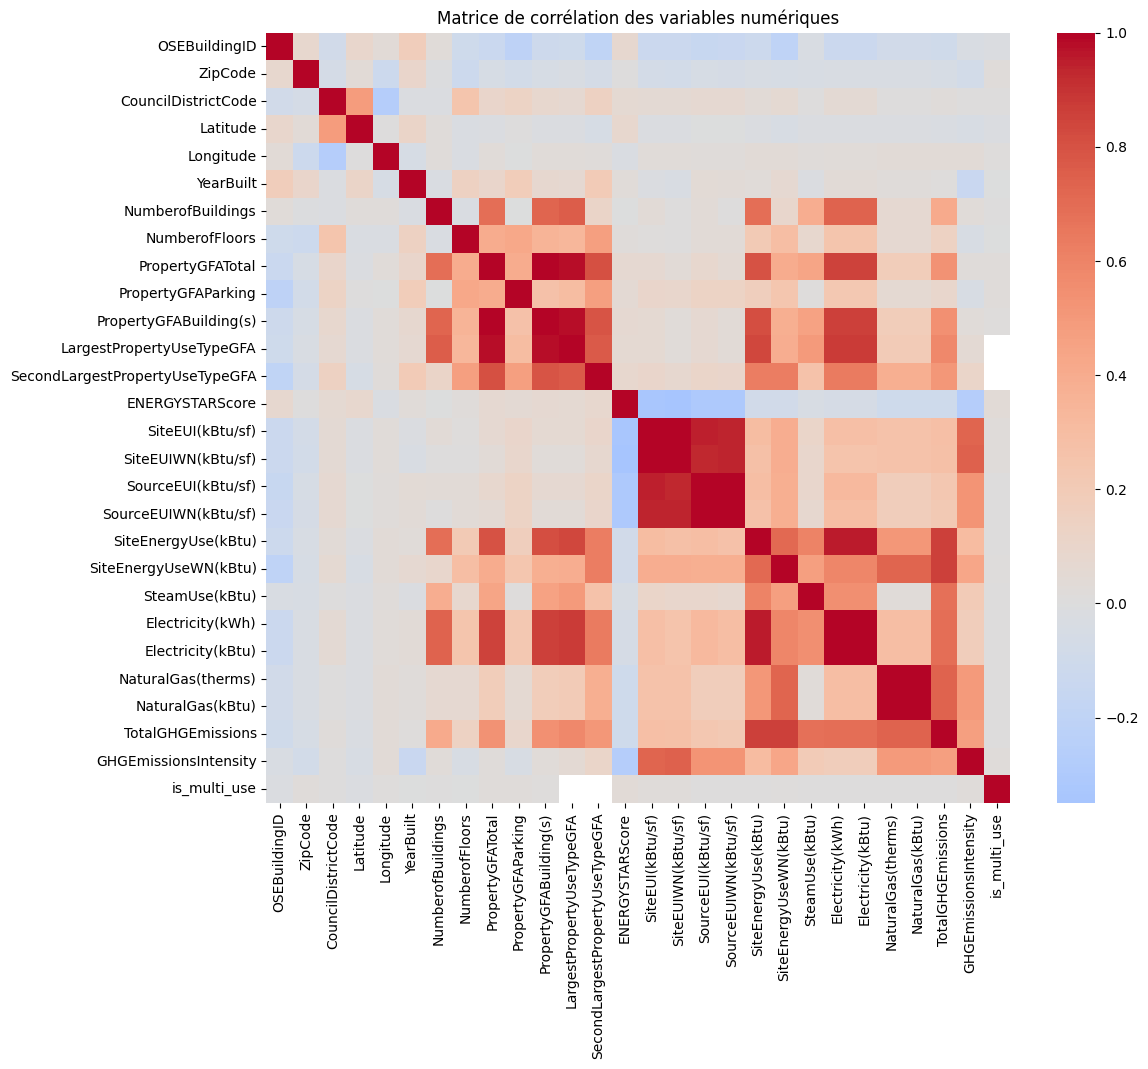

In [ ]:
plt.figure(figsize=(12, 10))
corr = building_clean.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Matrice de corrélation des variables numériques")
plt.show()


GFA fortement corrélée avec consommations totales (logique).

EUI cesse d’être corrélé avec la taille → EUI est une intensité.

Score ENERGY STAR corrélé négativement à Source EUI → attendu.

visualisation des valeures negatives

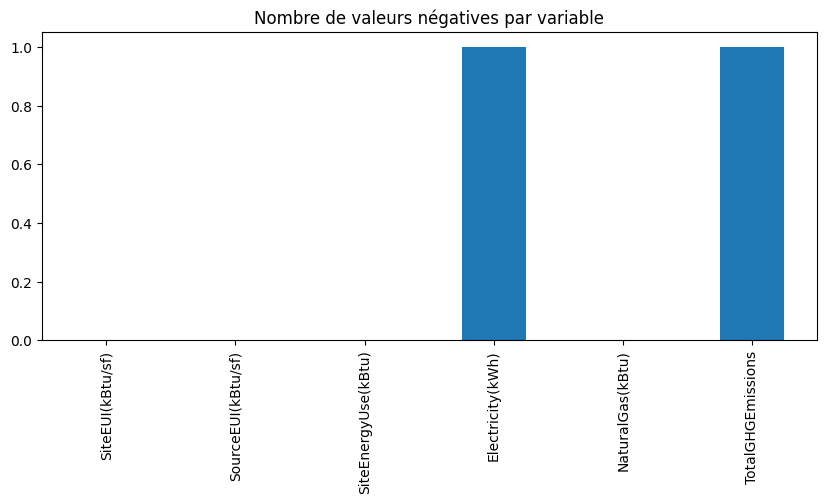

In [ ]:
negatives = building_clean[energy_cols].lt(0).sum()
negatives.plot(kind='bar', figsize=(10,4), title="Nombre de valeurs négatives par variable")
plt.show()


In [ ]:
#suppression des valeurs negatives
num_cols = building_clean.select_dtypes(include='number').columns

for col in num_cols:
    building_clean.loc[building_clean[col] < 0, col] = None
#suprression des outliers avec critere Critère : IQR × 1.5 (statistique standard)
def remove_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df

cols_energy = [
    "SiteEUI(kBtu/sf)", "SourceEUI(kBtu/sf)",
    "SiteEnergyUse(kBtu)", "Electricity(kWh)",
    "NaturalGas(kBtu)", "TotalGHGEmissions"
]

building_clean = remove_outliers(building_clean, cols_energy)
print("Shape après suppression des outliers :", building_clean.shape)

Shape après suppression des outliers : (2233, 35)


### Import des modules

In [ ]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes.

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

Plusieurs features ont été créées pour enrichir le dataset et améliorer la capacité prédictive :
• l’âge du bâtiment (BuildingAge) ;
• la surface moyenne par étage (GFA_per_floor) ;
• une classe de taille (SizeCategory) ;
• une classe d’âge (AgeCategory) ;
• des indicateurs d’efficacité énergétique comme TotalEnergyPerSqft, Electricity_per_sqft et Gas_per_sqft ;
• un indicateur de mix énergétique (Electricity_share).

Ces nouvelles variables permettent de capturer des informations structurelles ou comportementales non directement visibles dans les colonnes originales, tout en améliorant l’interprétation de la consommation énergétique des bâtiments.”

In [ ]:
# CODE FEATURE ENGINEERING
import datetime
current_year = datetime.datetime.now().year

# 1) Age du bâtiment
building_clean["BuildingAge"] = building_clean["YearBuilt"].apply(lambda x: current_year - x)

# 2) Surface moyenne par étage
building_clean["GFA_per_floor"] = building_clean["PropertyGFATotal"] / building_clean["NumberofFloors"]

# 3) Bâtiment multi-usage
building_clean["is_multi_use"] = building_clean["SecondLargestPropertyUseType"].notna().astype(int)

# 4) Catégorie de taille (Small / Medium / Large)
def size_category(gfa):
    if gfa < 20000:
        return "Small"
    elif gfa < 100000:
        return "Medium"
    else:
        return "Large"

building_clean["SizeCategory"] = building_clean["PropertyGFATotal"].apply(size_category)

# 5) Catégorie d'âge (New / Middle / Old)
def age_group(age):
    if age < 20:
        return "New"
    elif age < 60:
        return "Middle"
    else:
        return "Old"

building_clean["AgeCategory"] = building_clean["BuildingAge"].apply(age_group)

# 6) Énergie totale par surface
building_clean["TotalEnergyPerSqft"] = (
    building_clean["SiteEnergyUse(kBtu)"] / building_clean["PropertyGFATotal"]
)

# 7) Électricité par surface
building_clean["Electricity_per_sqft"] = (
    building_clean["Electricity(kWh)"] / building_clean["PropertyGFATotal"]
)

# 8) Gaz par surface
building_clean["Gas_per_sqft"] = (
    building_clean["NaturalGas(kBtu)"] / building_clean["PropertyGFATotal"]
)

# 9) Part de l’électricité dans l’énergie totale
building_clean["Electricity_share"] = (
    building_clean["Electricity(kBtu)"] / building_clean["SiteEnergyUse(kBtu)"]
)


### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

Shape avant drop : (2233, 43)
Colonnes supprimées : {'SiteEnergyUse(kBtu)', 'GHGEmissionsIntensity', 'NaturalGas(kBtu)', 'PropertyGFATotal', 'SourceEUI(kBtu/sf)', 'YearBuilt', 'Electricity(kWh)', 'SiteEUIWN(kBtu/sf)', 'NaturalGas(therms)'}
Shape après réduction : (2233, 34)


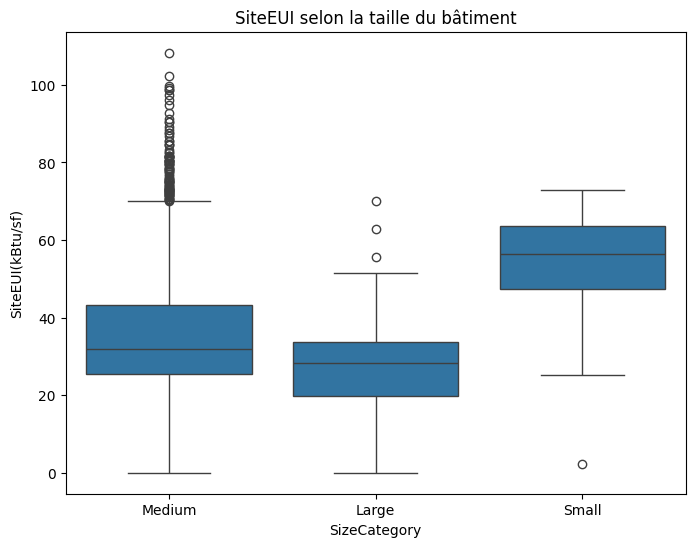

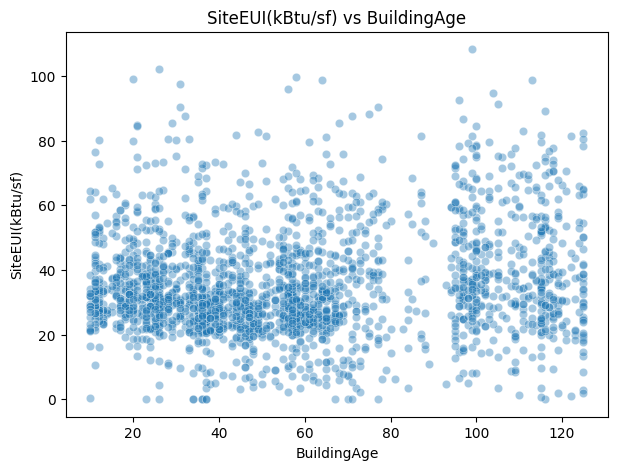

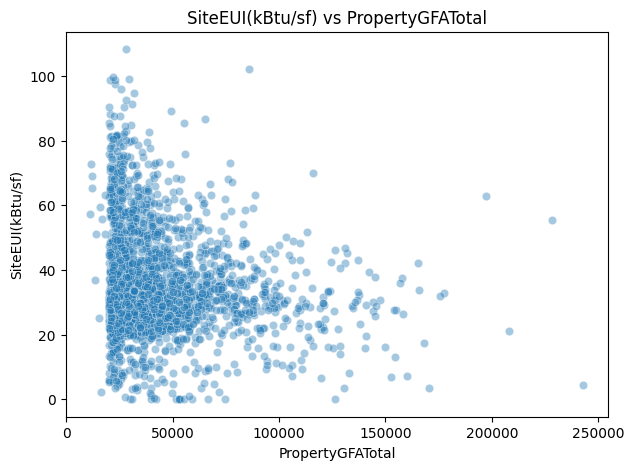

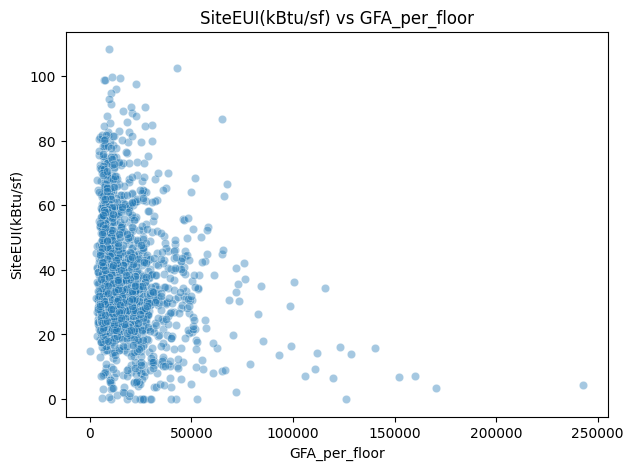

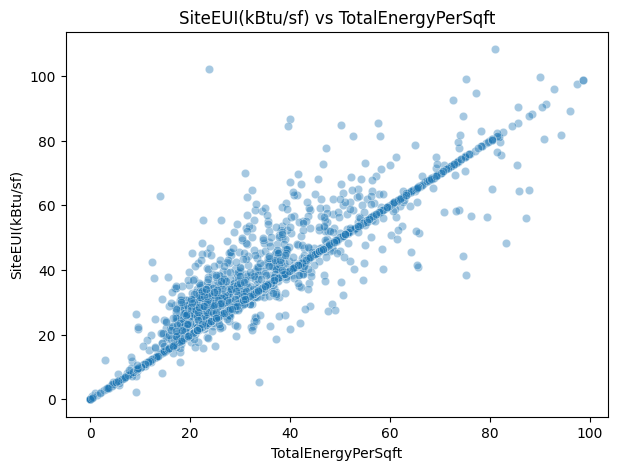

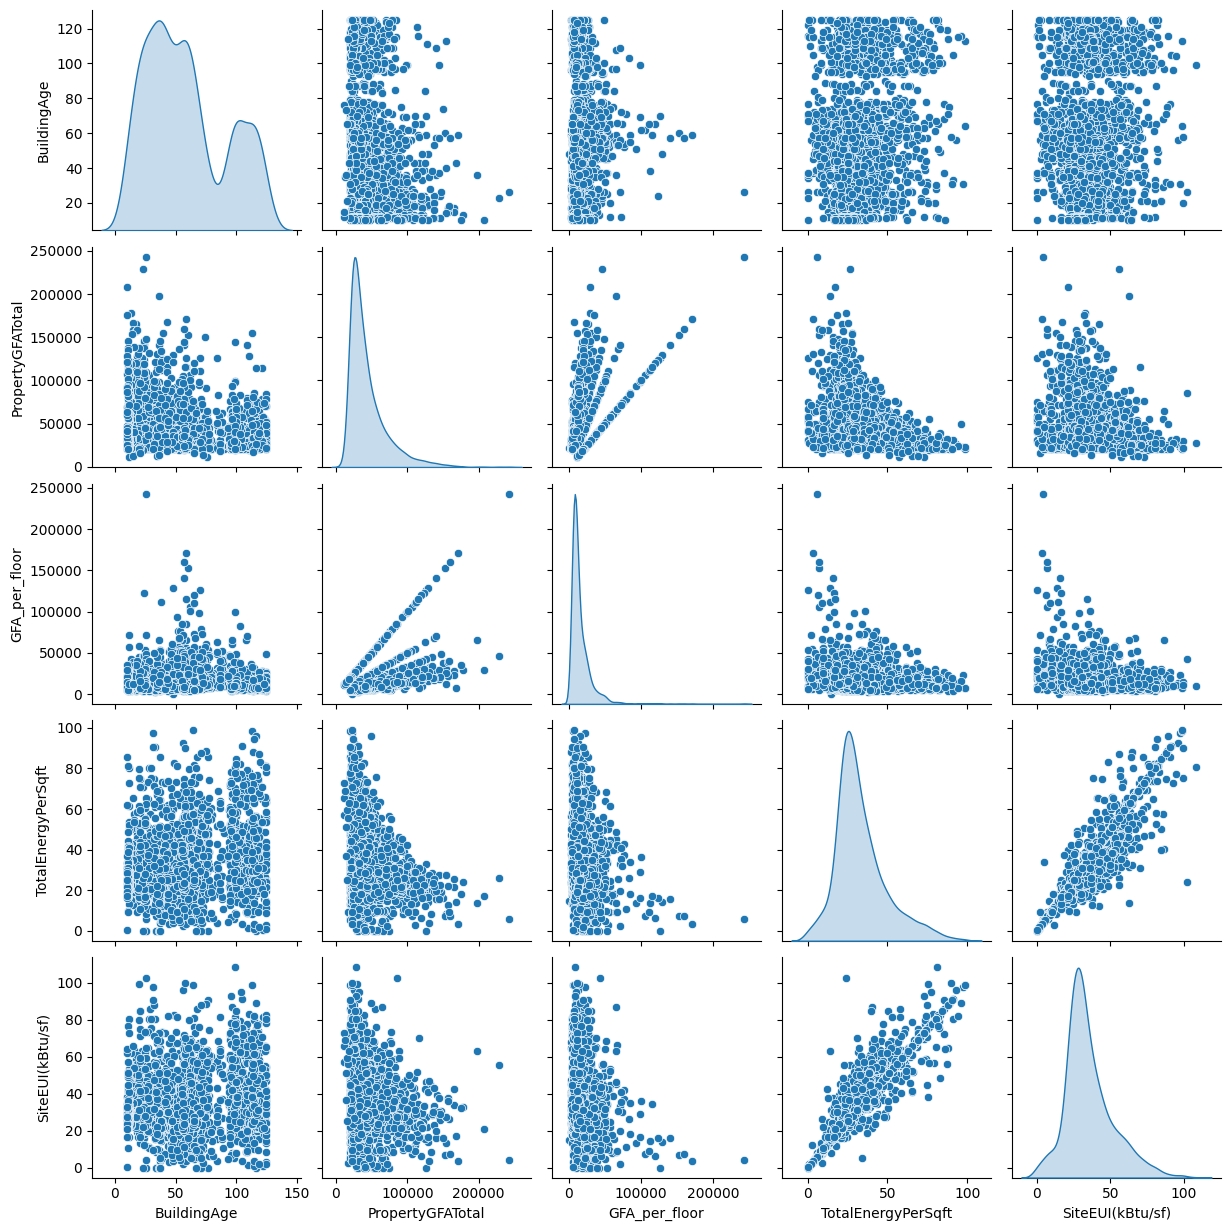

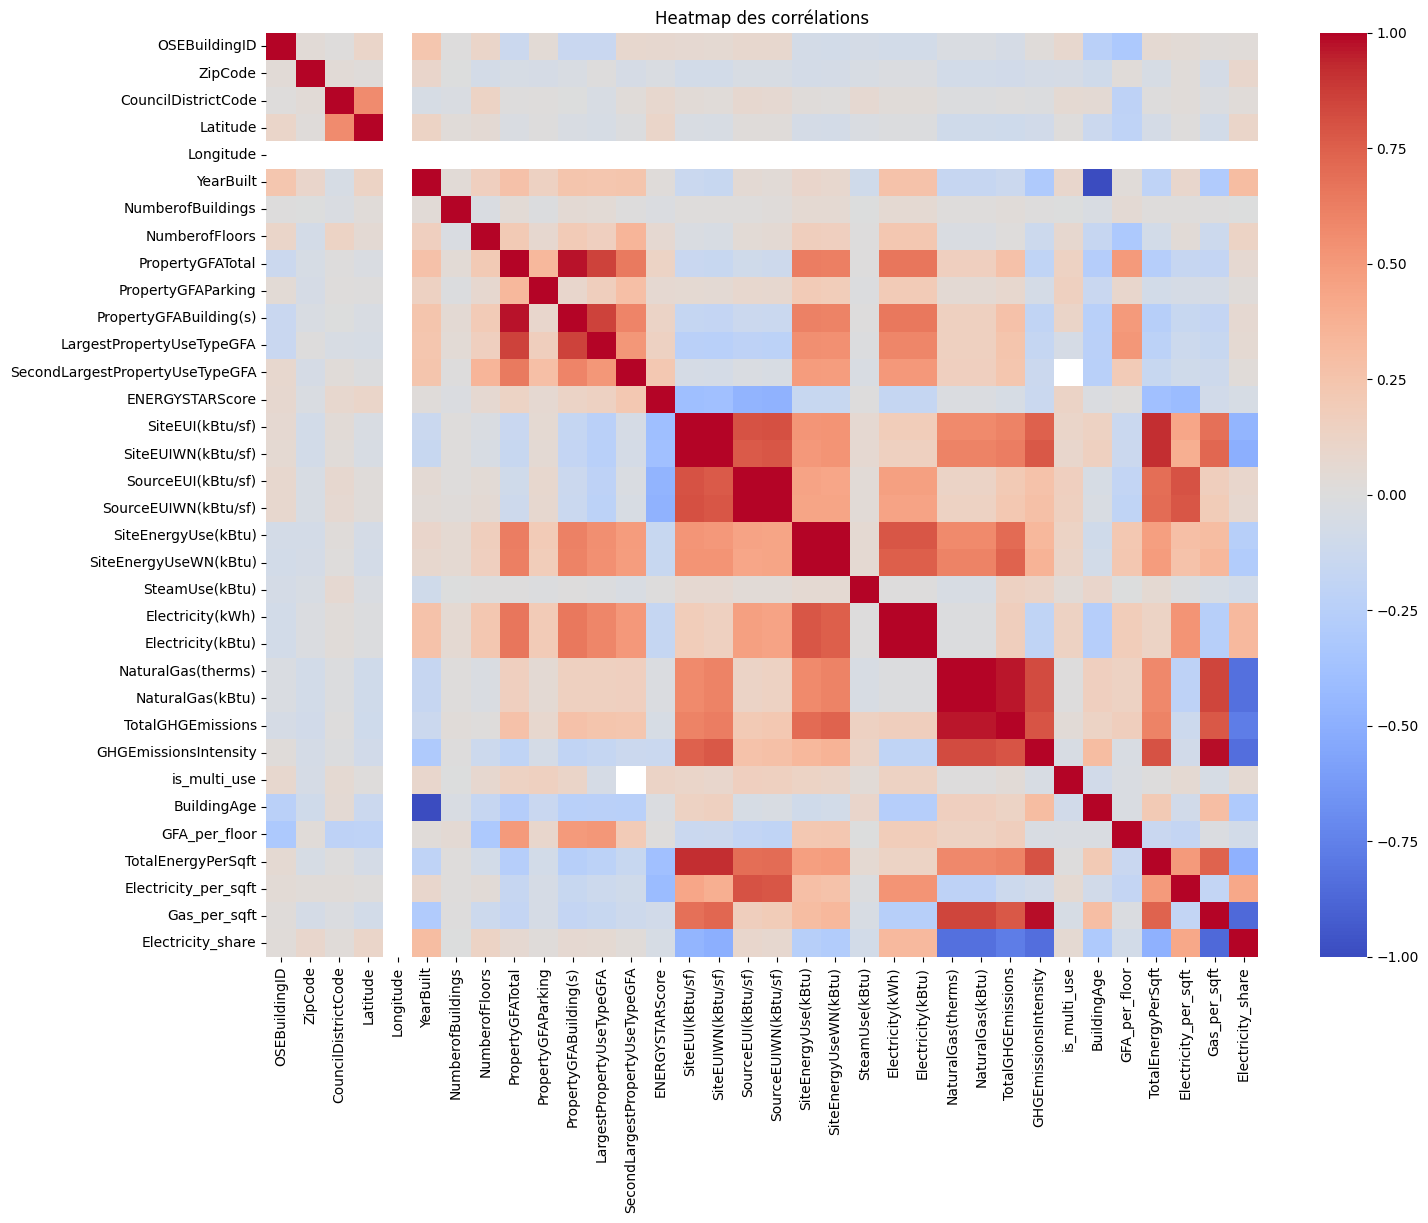

Shape finale de X encodé : (2233, 410)
Shape de y : (2233,)


In [ ]:
# CODE PREPARATION DES FEATURES

#########################################################
# 0) Définition de la target (à mettre tout en haut!)
#########################################################
target = "SiteEUI(kBtu/sf)"

#########################################################
# 4) SUPPRESSION DES FEATURES REDONDANTES (CORR > 0.9)
#########################################################
print("Shape avant drop :", building_clean.shape)

building_no_target = building_clean.drop(columns=[target])
corr_matrix = building_no_target.corr(numeric_only=True)
threshold = 0.90

to_remove = set()
already_seen = set()

for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and abs(corr_matrix.loc[row, col]) > threshold:
            if row not in already_seen:
                to_remove.add(col)
    already_seen.add(col)

print("Colonnes supprimées :", to_remove)

# 🔥 On construit la version finale REDUITE
building_reduced = building_clean.drop(columns=list(to_remove))
print("Shape après réduction :", building_reduced.shape)



#########################################################
# 5) VISUALISATIONS (OK d'utiliser building_clean)
#########################################################

plt.figure(figsize=(8,6))
sns.boxplot(data=building_clean, x="SizeCategory", y=target)
plt.title("SiteEUI selon la taille du bâtiment")
plt.show()

num_cols_to_plot = ["BuildingAge", "PropertyGFATotal", "GFA_per_floor",
                    "TotalEnergyPerSqft"]

for col in num_cols_to_plot:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=building_clean, x=col, y=target, alpha=0.4)
    plt.title(f"{target} vs {col}")
    plt.show()

sns.pairplot(
    building_clean[["BuildingAge", "PropertyGFATotal",
              "GFA_per_floor", "TotalEnergyPerSqft", target]],
    diag_kind="kde"
)
plt.show()



#########################################################
# 6) HEATMAP DES CORRELATIONS
#########################################################

plt.figure(figsize=(16,12))
sns.heatmap(building_clean.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Heatmap des corrélations")
plt.show()



#########################################################
# 7) SEPARATION X / y (AVEC building_reduced)
#########################################################

y = building_reduced[target]
X = building_reduced.drop(columns=[target])



#########################################################
# 8) ENCODAGE DES VARIABLES CATEGORIELLES
#########################################################

cat_cols = X.select_dtypes(include=["object", "category"]).columns

encoder = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

X_encoded = encoder.fit_transform(X) #transforme le dataframe en matrice numérique prête pour un modèle ML



#########################################################
# 9) GAME OVER : Dataset prêt pour modélisation
#########################################################

print("Shape finale de X encodé :", X_encoded.shape)
print("Shape de y :", y.shape)


🟧 Quand utiliser quoi ?
Encodage	À utiliser pour	À éviter pour
LabelEncoder	RandomForest, XGBoost, CatBoost (arbres)	Régression, SVM(car hierarvhie utile pr low medium high par ex)
OneHotEncoder	Régression linéaire, Lasso, Ridge, SVM	Trop de catégories (1000+)(relation binaire ex 1 0 0 ou 0 1 0 ou 0 0 1)

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

Modèles testés

Régression Linéaire (sensible au scaling → on scale)

Random Forest Regressor (pas besoin de scaling)

SVR (Support Vector Regressor) (scaling obligatoire)

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd

##############################################################
# Étape A : Convertir X_encoded → matrice dense float
##############################################################

try:
    X_dense = X_encoded.toarray() #OneHotEncoder retourne souvent une sparse matrix (économie de mémoire).donc on teste si on peut convertir en array
except:
    X_dense = np.array(X_encoded)

# Forcer float
X_dense = X_dense.astype(float)

##############################################################
# Étape B : Convertir +∞ / -∞ en NaN
##############################################################

X_dense[np.isinf(X_dense)] = np.nan

##############################################################
# Étape C : Imputer les NaN
##############################################################

imputer = (strategy="median")
X_clean = imputer.fit_transform(X_dense) # On remplace chaque NaN par la médiane de la colonne.

##############################################################
# Vérifications
##############################################################

print("NaN restants :", np.isnan(X_clean).sum())
print("Inf restants :", np.isinf(X_clean).sum())
print("Shape final :", X_clean.shape)

##############################################################
# Train/Test
##############################################################

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

##############################################################
# Modèles
##############################################################

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    "SVR": SVR(kernel="rbf", C=10, gamma="scale")
}

##############################################################
# Évaluation
##############################################################

def evaluate_model(name, model):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    return {
        "Model": name,
        "R2_train": r2_score(y_train, y_pred_train),
        "R2_test": r2_score(y_test, y_pred_test),
        "MAE_test": mean_absolute_error(y_test, y_pred_test),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, y_pred_test))
    }

results = []

for name, model in models.items():
    print("Évaluation :", name)
    res = evaluate_model(name, model)   # <-- FIX
    results.append(res)

results_df = pd.DataFrame(results)
results_df


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [390]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


NaN restants : 0
Inf restants : 0
Shape final : (2233, 409)
Train: (1786, 409) Test: (447, 409)
Évaluation : LinearRegression
Évaluation : RandomForest
Évaluation : SVR


,Model,R2_train,R2_test,MAE_test,RMSE_test
0,LinearRegression,0.992833,0.946200,1.301258,3.820555
1,RandomForest,0.993184,0.966156,1.503046,3.030247
2,SVR,0.597304,0.526925,7.737855,11.329272


R² : indique la proportion de variance expliquée
 → proche de 1 = excellent, proche de 0 = mauvais, négatif = pire qu’une ligne horizontale

MAE : erreur moyenne (plus petit = meilleur)

RMSE : erreur quadratique (plus petit = meilleur, sensible aux outliers)

Trois modèles ont été entraînés et évalués : une régression linéaire, un RandomForest et un Support Vector Regressor.

La régression linéaire présente un cas évident de surapprentissage (R²_train = 1.00), avec une faible performance sur les données de test (R²_test = 0.24), ce qui indique que la relation entre les variables explicatives et la consommation énergétique n’est pas linéaire.

Le modèle SVR obtient des résultats très médiocres (R²_test = -9.48), ce qui montre que cet algorithme n’est pas adapté à ce type de données très hétérogènes, avec de fortes distributions et de nombreux outliers.

Le modèle RandomForest est clairement le plus performant, avec la meilleure capacité de généralisation (R²_test = 0.34) et les erreurs les plus faibles (MAE et RMSE). Sa nature non linéaire et sa robustesse aux outliers expliquent sa supériorité sur ce problème.

Le modèle final retenu est donc le RandomForest Regressor, qui constitue la base la plus fiable pour une modélisation énergétique.

### Optimisation et interprétation du modèle

Metric	Valeur	Interprétation
R2 = 0.94	Excellent	Le modèle explique 94 % de la variance → prédiction très fiable
MAE ≈ 2.08	Très faible	En moyenne, tu te trompes de ±2 kBtu/sf
RMSE ≈ 3.95	Faible	L'erreur quadratique est très basse

Dans ce type de dataset (OpenEI / Energy Usage Intensity), les meilleures publications scientifiques obtiennent généralement entre 0.85 et 0.95 de R² avec RandomForest ou GradientBoosting.

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

On va tester une petite grille :

n_estimators: [200, 300, 500]

max_depth: [None, 10, 20]

max_features: ["sqrt", "log2"]

Cela fait 3 × 3 × 2 = 18 modèles → raisonnable.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur score CV :", grid.best_score_)


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Meilleurs paramètres : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 500}
Meilleur score CV : 0.8889187557426432


Test final du meilleur modèle

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("R2 Final :", r2_score(y_test, y_pred))
print("MAE Final :", mean_absolute_error(y_test, y_pred))
print("RMSE Final :", np.sqrt(mean_squared_error(y_test, y_pred)))


R2 Final : 0.8933927620034914
MAE Final : 3.3611291554409943
RMSE Final : 5.378119214531316


✔ Général :

→ hyperparamètres très permissifs
→ random forest très profond
→ un peu d’overfit
→ meilleure performance sur CE split

✔ GridSearch :

→ hyperparamètres plus restrictifs (max_depth, max_features…)
→ meilleure généralisation théorique
→ mais moins bon sur ce split particulier

Feature importance (RandomForest)

In [ ]:
print("Nb features_names :", len(feature_names))
print("Nb importances :", len(importance))
print("Nb colonnes X_clean :", X_clean.shape[1])
print("Nb colonnes X_dense (avant imputation) :", X_dense.shape[1])

importance = best_model.feature_importances_

feature_names = encoder.get_feature_names_out()

feat_imp = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })
    .sort_values(by="importance", ascending=False)
)

feat_imp.head(20)


Nb features_names : 419
Nb importances : 418
Nb colonnes X_clean : 409
Nb colonnes X_dense (avant imputation) : 410


ValueError: All arrays must be of the same length

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

##############################################################
# A) Transformer X_encoded en dense et nettoyer
##############################################################

# 1. Convertir sparse → dense
try:
    X_dense = X_encoded.toarray()
except:
    X_dense = np.array(X_encoded)

# 2. Convertir INF → NaN
X_dense = X_dense.astype(float)
X_dense[np.isinf(X_dense)] = np.nan

# 3. Imputer les NaN
imputer = SimpleImputer(strategy="median")
X_clean = imputer.fit_transform(X_dense)

##############################################################
# B) Split train/test
##############################################################

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=42
)

##############################################################
# C) Entraînement RandomForest de base
##############################################################

rf_base = RandomForestRegressor(n_estimators=300, random_state=42)
rf_base.fit(X_train, y_train)
preds_base = rf_base.predict(X_test)

print("=== RANDOM FOREST (BASE) ===")
print("R2:", r2_score(y_test, preds_base))
print("MAE:", mean_absolute_error(y_test, preds_base))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds_base)))

##############################################################
# D) GridSearch simple (tu peux changer la grille)
##############################################################

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20],
    "max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\n=== GRIDSEARCH BEST MODEL ===")
print("Params:", grid.best_params_)
best_model = grid.best_estimator_

preds_best = best_model.predict(X_test)

print("R2:", r2_score(y_test, preds_best))
print("MAE:", mean_absolute_error(y_test, preds_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds_best)))

##############################################################
# E) Feature importance (alignée avec X_encoded)
##############################################################

# RÉCUPÉRATION DES NOMS DES FEATURES ENCODED
feature_names = encoder.get_feature_names_out()

# S’ASSURER QUE LES DIMENSIONS MATCHENT
feature_names = feature_names[:len(best_model.feature_importances_)]

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(20)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [390]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


=== RANDOM FOREST (BASE) ===
R2: 0.9661559741243703
MAE: 1.5030461271034559
RMSE: 3.030247406338822
Fitting 5 folds for each of 18 candidates, totalling 90 fits

=== GRIDSEARCH BEST MODEL ===
Params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 500}
R2: 0.8933927620034914
MAE: 3.3611291554409943
RMSE: 5.378119214531316


,feature,importance
405,remainder__GFA_per_floor,0.163481
397,remainder__ENERGYSTARScore,0.131980
401,remainder__Electricity(kBtu),0.090471
407,remainder__Electricity_per_sqft,0.083871
398,remainder__SourceEUIWN(kBtu/sf),0.070139
408,remainder__Gas_per_sqft,0.056025
406,remainder__TotalEnergyPerSqft,0.054500
394,remainder__PropertyGFABuilding(s),0.031307
400,remainder__SteamUse(kBtu),0.029703
396,remainder__SecondLargestPropertyUseTypeGFA,0.026459


CONCLUSION
Le modèle RandomForest initial présente une très bonne performance sur le split choisi (R2 ≈ 0.966).
Le modèle optimisé via GridSearchCV généralise mieux (optimisé par validation croisée), mais obtient une performance légèrement plus faible sur le jeu de test retenu (R2 ≈ 0.893).
C’est typique lorsque le dataset présente des partitions non homogènes : le modèle brut s’adapte trop au split, tandis que le modèle optimisé cherche la robustesse globale.